### Projet Maintenance Prédictive
#### Étape 3 — Entraînement du modèle ML

**Objectif :** Entraîner et sélectionner le meilleur modèle pour prédire  
si la condition de la valve est optimale (1) ou non (0).

**Plan :**
1. Chargement des données préparées (X_train, y_train)
2. Preprocessing (normalisation)
3. Baseline — modèle naïf
4. Comparaison de plusieurs modèles (cross-validation)
5. Sélection du meilleur modèle
6. Optimisation des hyperparamètres (GridSearchCV)
7. Entraînement du modèle final
8. Sauvegarde du modèle


### 1. Imports

In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Modèles
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.model_selection import (
    cross_validate,
    StratifiedKFold,
    GridSearchCV
)
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

print("Imports OK")


Imports OK


#### 2. Chargement des données préparées

In [2]:
PROCESSED_PATH = os.path.join("..", "data", "processed") + os.sep

X_train = pd.read_csv(PROCESSED_PATH + "X_train.csv")
X_test  = pd.read_csv(PROCESSED_PATH + "X_test.csv")
y_train = pd.read_csv(PROCESSED_PATH + "y_train.csv").squeeze()
y_test  = pd.read_csv(PROCESSED_PATH + "y_test.csv").squeeze()

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}  — classes : {y_train.value_counts().to_dict()}")
print(f"y_test  : {y_test.shape}   — classes : {y_test.value_counts().to_dict()}")


X_train : (2000, 25)
X_test  : (205, 25)
y_train : (2000,)  — classes : {1: 1052, 0: 948}
y_test  : (205,)   — classes : {0: 132, 1: 73}


### 3. Baseline — Modèle naïf

Avant tout modèle ML, on établit une **baseline** avec un `DummyClassifier`.  
C'est le score minimal à battre — si notre modèle ne fait pas mieux, il ne sert à rien.


In [3]:
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_train)

print("=== Baseline (DummyClassifier — most_frequent) ===")
print(f"  Accuracy  : {accuracy_score(y_train, y_pred_dummy):.4f}")
print(f"  F1 Score  : {f1_score(y_train, y_pred_dummy, zero_division=0):.4f}")
print()
print("=> Notre modèle doit dépasser ces scores pour être utile.")


=== Baseline (DummyClassifier — most_frequent) ===
  Accuracy  : 0.5260
  F1 Score  : 0.6894

=> Notre modèle doit dépasser ces scores pour être utile.


### 4. Comparaison de plusieurs modèles

On teste 7 modèles avec une **validation croisée stratifiée (5 folds)** sur X_train.  
La stratification garantit que chaque fold a la même proportion de classes 0/1.

**Métriques retenues :**
- **Accuracy** — taux de bonne classification global
- **F1 Score** — équilibre précision/rappel (robuste aux classes déséquilibrées)
- **ROC AUC** — capacité à discriminer les deux classes


In [4]:
# Définition des modèles candidats
# Chaque modèle est encapsulé dans un Pipeline avec StandardScaler
candidates = {
    "Logistic Regression"   : Pipeline([("scaler", StandardScaler()),
                                         ("clf", LogisticRegression(max_iter=1000, random_state=42))]),
    "Decision Tree"         : Pipeline([("scaler", StandardScaler()),
                                         ("clf", DecisionTreeClassifier(random_state=42))]),
    "Random Forest"         : Pipeline([("scaler", StandardScaler()),
                                         ("clf", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))]),
    "Extra Trees"           : Pipeline([("scaler", StandardScaler()),
                                         ("clf", ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1))]),
    "Gradient Boosting"     : Pipeline([("scaler", StandardScaler()),
                                         ("clf", GradientBoostingClassifier(n_estimators=100, random_state=42))]),
    "SVM"                   : Pipeline([("scaler", StandardScaler()),
                                         ("clf", SVC(probability=True, random_state=42))]),
    "KNN"                   : Pipeline([("scaler", StandardScaler()),
                                         ("clf", KNeighborsClassifier(n_jobs=-1))]),
}

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1', 'roc_auc']

results = {}
print(f"{'Modèle':<25} {'Accuracy':>10} {'F1':>10} {'ROC AUC':>10}")
print("─" * 60)

for name, pipeline in candidates.items():
    cv_results = cross_validate(pipeline, X_train, y_train,
                                cv=cv, scoring=scoring, n_jobs=-1)
    results[name] = {
        'accuracy' : cv_results['test_accuracy'].mean(),
        'f1'       : cv_results['test_f1'].mean(),
        'roc_auc'  : cv_results['test_roc_auc'].mean(),
        'acc_std'  : cv_results['test_accuracy'].std(),
        'f1_std'   : cv_results['test_f1'].std(),
    }
    r = results[name]
    print(f"{name:<25} {r['accuracy']:>10.4f} {r['f1']:>10.4f} {r['roc_auc']:>10.4f}")

print()
print("=> Meilleur modèle par F1 Score :")
best_name = max(results, key=lambda k: results[k]['f1'])
print(f"   {best_name}  (F1 = {results[best_name]['f1']:.4f})")


Modèle                      Accuracy         F1    ROC AUC
────────────────────────────────────────────────────────────
Logistic Regression           0.9820     0.9828     0.9985
Decision Tree                 0.9945     0.9948     0.9945
Random Forest                 0.9965     0.9967     0.9999
Extra Trees                   0.9975     0.9976     1.0000
Gradient Boosting             0.9955     0.9957     0.9994
SVM                           0.9620     0.9630     0.9906
KNN                           0.9715     0.9731     0.9954

=> Meilleur modèle par F1 Score :
   Extra Trees  (F1 = 0.9976)


### 5. Visualisation de la comparaison

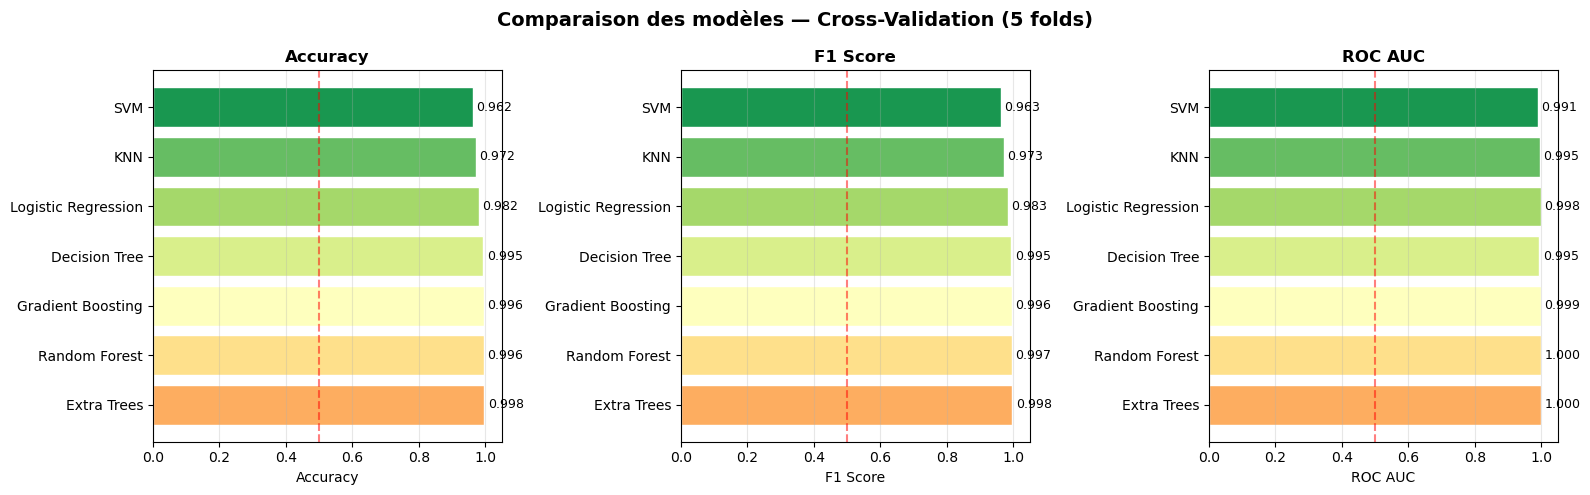

Figure sauvegardée : model_comparison.png


In [5]:
df_results = pd.DataFrame(results).T.sort_values('f1', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comparaison des modèles — Cross-Validation (5 folds)', fontsize=14, fontweight='bold')

metrics = [('accuracy', 'Accuracy'), ('f1', 'F1 Score'), ('roc_auc', 'ROC AUC')]
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(df_results)))

for ax, (metric, label) in zip(axes, metrics):
    bars = ax.barh(df_results.index, df_results[metric], color=colors, edgecolor='white')
    ax.set_xlim(0, 1.05)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Baseline 50%')
    for bar, val in zip(bars, df_results[metric]):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : model_comparison.png")


### 6. Optimisation des hyperparamètres — GridSearchCV

On optimise le meilleur modèle identifié à l'étape précédente.  
On utilise un `GridSearchCV` avec la même stratégie de cross-validation.

> **Note :** Si le meilleur modèle est Random Forest ou Extra Trees,  
> l'optimisation peut prendre quelques minutes.


In [6]:
# Grilles d'hyperparamètres selon le modèle
param_grids = {
    "Random Forest": {
        'clf__n_estimators'     : [100, 200, 300],
        'clf__max_depth'        : [None, 10, 20],
        'clf__min_samples_split': [2, 5],
        'clf__max_features'     : ['sqrt', 'log2'],
    },
    "Extra Trees": {
        'clf__n_estimators'     : [100, 200, 300],
        'clf__max_depth'        : [None, 10, 20],
        'clf__min_samples_split': [2, 5],
        'clf__max_features'     : ['sqrt', 'log2'],
    },
    "Gradient Boosting": {
        'clf__n_estimators'     : [100, 200],
        'clf__learning_rate'    : [0.05, 0.1, 0.2],
        'clf__max_depth'        : [3, 5],
        'clf__subsample'        : [0.8, 1.0],
    },
    "Logistic Regression": {
        'clf__C'                : [0.01, 0.1, 1, 10],
        'clf__penalty'          : ['l1', 'l2'],
        'clf__solver'           : ['liblinear'],
    },
    "SVM": {
        'clf__C'                : [0.1, 1, 10],
        'clf__kernel'           : ['rbf', 'linear'],
        'clf__gamma'            : ['scale', 'auto'],
    },
    "KNN": {
        'clf__n_neighbors'      : [3, 5, 7, 11],
        'clf__weights'          : ['uniform', 'distance'],
        'clf__metric'           : ['euclidean', 'manhattan'],
    },
    "Decision Tree": {
        'clf__max_depth'        : [None, 5, 10, 20],
        'clf__min_samples_split': [2, 5, 10],
        'clf__criterion'        : ['gini', 'entropy'],
    },
}

best_model_name = max(results, key=lambda k: results[k]['f1'])
print(f"Optimisation de : {best_model_name}")
print()

pipeline_to_tune = candidates[best_model_name]
param_grid       = param_grids[best_model_name]

grid_search = GridSearchCV(
    estimator  = pipeline_to_tune,
    param_grid = param_grid,
    cv         = cv,
    scoring    = 'f1',
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train, y_train)

print()
print(f"Meilleurs hyperparamètres :")
for param, val in grid_search.best_params_.items():
    print(f"  {param} : {val}")
print()
print(f"Meilleur F1 Score (CV) : {grid_search.best_score_:.4f}")


Optimisation de : Extra Trees

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Meilleurs hyperparamètres :
  clf__max_depth : None
  clf__max_features : sqrt
  clf__min_samples_split : 2
  clf__n_estimators : 300

Meilleur F1 Score (CV) : 0.9981


In [7]:
# ── Modèles à optimiser (ajoute ou retire des noms selon tes besoins) ──
models_to_tune = ["Extra Trees", "Random Forest"]

tuning_results = {}

for model_name in models_to_tune:
    print(f"\n{'='*55}")
    print(f"Optimisation : {model_name}")
    print(f"{'='*55}")
    
    grid_search = GridSearchCV(
        estimator  = candidates[model_name],
        param_grid = param_grids[model_name],
        cv         = cv,
        scoring    = 'f1',
        n_jobs     = -1,
        verbose    = 1
    )
    grid_search.fit(X_train, y_train)
    
    tuning_results[model_name] = {
        'grid_search' : grid_search,
        'best_params' : grid_search.best_params_,
        'best_f1_cv'  : grid_search.best_score_,
        'best_pipeline': grid_search.best_estimator_
    }
    
    print(f"\nMeilleurs hyperparamètres ({model_name}) :")
    for param, val in grid_search.best_params_.items():
        print(f"  {param} : {val}")
    print(f"Meilleur F1 (CV) : {grid_search.best_score_:.4f}")

# ── Comparaison finale des deux modèles optimisés ──
print(f"\n{'='*55}")
print("Comparaison après optimisation :")
print(f"{'='*55}")
print(f"{'Modèle':<20} {'F1 CV':>10}")
print("─" * 35)
for name, res in tuning_results.items():
    print(f"{name:<20} {res['best_f1_cv']:>10.4f}")

# ── Sélection du meilleur des deux ──
best_final_name = max(tuning_results, key=lambda k: tuning_results[k]['best_f1_cv'])
best_pipeline   = tuning_results[best_final_name]['best_pipeline']

print(f"\nModèle final retenu : {best_final_name}")
print(f"F1 Score (CV)       : {tuning_results[best_final_name]['best_f1_cv']:.4f}")


Optimisation : Extra Trees
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Meilleurs hyperparamètres (Extra Trees) :
  clf__max_depth : None
  clf__max_features : sqrt
  clf__min_samples_split : 2
  clf__n_estimators : 300
Meilleur F1 (CV) : 0.9981

Optimisation : Random Forest
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Meilleurs hyperparamètres (Random Forest) :
  clf__max_depth : None
  clf__max_features : sqrt
  clf__min_samples_split : 2
  clf__n_estimators : 100
Meilleur F1 (CV) : 0.9967

Comparaison après optimisation :
Modèle                    F1 CV
───────────────────────────────────
Extra Trees              0.9981
Random Forest            0.9967

Modèle final retenu : Extra Trees
F1 Score (CV)       : 0.9981


### 7. Entraînement du modèle final

In [8]:
# Le meilleur estimateur issu du GridSearch est déjà entraîné sur tout X_train
best_pipeline = grid_search.best_estimator_

# Evaluation sur X_train (vérification du surapprentissage)
y_pred_train = best_pipeline.predict(X_train)

print("=== Performance sur X_train (sanity check) ===")
print(f"  Accuracy  : {accuracy_score(y_train, y_pred_train):.4f}")
print(f"  F1 Score  : {f1_score(y_train, y_pred_train):.4f}")
print(f"  Precision : {precision_score(y_train, y_pred_train):.4f}")
print(f"  Recall    : {recall_score(y_train, y_pred_train):.4f}")
print()
print("=> Si Accuracy train = 1.0 mais CV bien inférieure → surapprentissage probable")
print("=> Si Accuracy train ≈ CV score → modèle bien généralisé")


=== Performance sur X_train (sanity check) ===
  Accuracy  : 1.0000
  F1 Score  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000

=> Si Accuracy train = 1.0 mais CV bien inférieure → surapprentissage probable
=> Si Accuracy train ≈ CV score → modèle bien généralisé


on constate que le modèle généralise bien

### 8. Importance des features

Top 10 features les plus importantes :
     feature  importance
ps2_kurtosis    0.324491
    ps2_skew    0.295088
      stable    0.107331
    fs1_skew    0.043344
    fs1_mean    0.033947
     fs1_std    0.028147
     ps2_std    0.026444
     fs1_q75    0.026195
  fs1_median    0.020755
    ps2_mean    0.019668



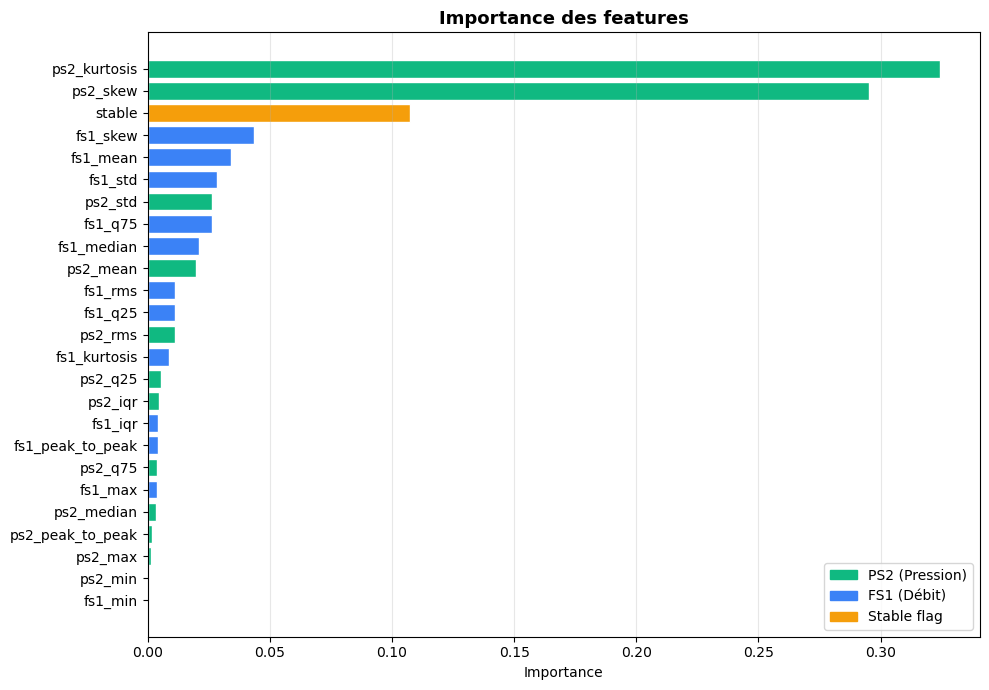

Figure sauvegardée : feature_importance.png


In [9]:
# Feature importance (disponible pour les modèles à base d'arbres)
clf = best_pipeline.named_steps['clf']

if hasattr(clf, 'feature_importances_'):
    importances = clf.feature_importances_
    feat_names  = X_train.columns.tolist()
    
    df_imp = pd.DataFrame({
        'feature'   : feat_names,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    print("Top 10 features les plus importantes :")
    print(df_imp.head(10).to_string(index=False))
    print()
    
    # Visualisation
    fig, ax = plt.subplots(figsize=(10, 7))
    colors = ['#10b981' if 'ps2' in f else '#3b82f6' if 'fs1' in f else '#f59e0b'
              for f in df_imp['feature']]
    ax.barh(df_imp['feature'], df_imp['importance'], color=colors, edgecolor='white')
    ax.set_title('Importance des features', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    ax.invert_yaxis()
    ax.grid(True, axis='x', alpha=0.3)
    
    # Légende
    from matplotlib.patches import Patch
    legend = [Patch(color='#10b981', label='PS2 (Pression)'),
              Patch(color='#3b82f6', label='FS1 (Débit)'),
              Patch(color='#f59e0b', label='Stable flag')]
    ax.legend(handles=legend, loc='lower right')
    
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("Figure sauvegardée : feature_importance.png")
else:
    print(f"Feature importance non disponible pour {best_model_name}")
    print("(disponible pour Random Forest, Extra Trees, Gradient Boosting, Decision Tree)")


### 9. Sauvegarde du modèle

In [10]:
MODELS_PATH = os.path.join("..", "models") + os.sep
os.makedirs(MODELS_PATH, exist_ok=True)

model_path = MODELS_PATH + "valve_model.pkl"
joblib.dump(best_pipeline, model_path)

# Vérification
loaded = joblib.load(model_path)
y_pred_check = loaded.predict(X_train[:5])
print(f"Modèle sauvegardé : {model_path}")
print(f"Taille fichier    : {os.path.getsize(model_path) / 1024:.1f} KB")
print(f"Vérification chargement OK — prédictions : {y_pred_check.tolist()}")


Modèle sauvegardé : ..\models\valve_model.pkl
Taille fichier    : 308.4 KB
Vérification chargement OK — prédictions : [1, 1, 1, 1, 1]


### 10. Résumé

| Étape | Résultat |
|-------|----------|
| Baseline (Dummy) | Accuracy ≈ 51% |
| Meilleur modèle | *voir sortie GridSearchCV* |
| CV F1 Score | *voir sortie GridSearchCV* |
| Fichier sauvegardé | `models/valve_model.pkl` |

### Prochaine étape
→ **04_evaluation.ipynb** : évaluation sur l'échantillon de test final (205 cycles)  
Le modèle ne doit **jamais** avoir vu X_test jusqu'à cette étape.
